In [2]:
import re 
import heapq
import matplotlib.pyplot as plt

In [3]:
def read_file(path):
    with open(path ,'r',encoding="utf-8") as f:
        return f.read()
    

Shakespeare = read_file("Complete works of shakespeare.txt")

In [6]:
import matplotlib.pyplot as plt

#Some stats of Shakespeare's Vocab:

Vocabulary = {}
for word in Shakespeare:
    if word in Vocabulary.keys():
        Vocabulary[word]+=1
    else:
        Vocabulary[word]=1
        

Token_ids =dict(sorted(Vocabulary.items()))

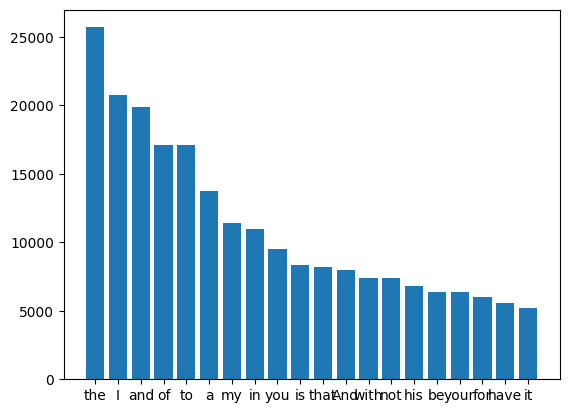

In [7]:
import heapq
n=20

top_n = heapq.nlargest(n, Token_ids.items(), key=lambda x: x[1])

words = [top[0] for top in top_n]
counts = [top[1] for top in top_n]

plt.bar(words,counts)
plt.show()

In [4]:
#Simple tokenizer:

class My_tokenizer:
    def __init__(self, vocab=None, size=None,tokens=None):

        if vocab!=None:
            self.size= len(vocab.items())
            self.vocab=vocab

        if tokens!=None:
            self.tokens=tokens
        
        self.text=None

    def clean_up(self,text):
        def clean_text(text):
            text = text.replace("\n", " ")
            text = re.sub(r"\s+", " ", text)
            text = text.replace(r"."," <eos.>")
            text = text.replace(r"?"," <eos?>")
            text = text.replace(r"!"," <eos!>")
            return text.strip()
        def split_text(text):
            text = re.split(" ",text)
            return text


        new_text = clean_text(text)
        new_text = split_text(new_text)
        return new_text
    def fit(self,text,size):
        Vocabulary = {}
        for word in text:
            if word in Vocabulary.keys():
                Vocabulary[word]+=1
            else:
                Vocabulary[word]=1
 
        
        
        sorted_words = heapq.nlargest(size, Vocabulary.items(), key=lambda x: x[1])

        vocab={}
        for idx in range(len(sorted_words)):
            tok = sorted_words[idx][0]
            vocab[tok]=idx

        vocab["<unk>"]=idx+1

        self.unk_key = idx+1

        self.size = len(vocab.keys())
        self.vocab= vocab

        print("Fitted!")

        return self.vocab, [self.vocab[key] for key in ["<eos.>","<eos!>","<eos?>"]]            

        
    def transform(self,text,vocal=True):
        new_text=[]
        ctr=0
        unk_key=self.unk_key
        for word in text:
            if word not in self.vocab.keys():
                new_text.append(unk_key)
                ctr+=1
            else: 
                new_text.append(self.vocab[word])
        if vocal:
            print("Text out of vocabulary:",ctr/len(text))
        return new_text
                

In [5]:
Tokenizer = My_tokenizer()
Cleaned=Tokenizer.clean_up(Shakespeare)
vocab,eos = Tokenizer.fit(Cleaned,10000)
Tokenized = Tokenizer.transform(Cleaned)



Fitted!
Text out of vocabulary: 0.07876151137280461


In [6]:
import numpy as np
class Simple_embedding:
    def __init__(self, embedding_length,id_length,Positional_encoding = "Sine",):

        self.size = embedding_length
        self.pos_encoding = Positional_encoding
        self.id_length= id_length

        self.mu=0

        self.var=1

    #Innitialize weights: 
        
    def set_means(self,mu,var):

        self.mu=mu
        self.var=var

    def initialize(self):
        A = np.random.normal(self.mu,np.sqrt(self.var),(self.id_length,self.size))
        

        self.embedding_table = A
        return A

    def pos_enc(self, length):
        if length ==0:
            return np.zeros(1)
        if self.pos_encoding == "Sine":

            range_points = np.arange(0,np.pi,np.pi/length)
            encoding = np.sin(range_points)
            return encoding
            
        else: 

            return np.zeros(length)
            
        #if Positional_encoding != "Sine":
        #    raise RuntimeWarning("no positional encoding selected")
              
    def set_end_points(self, end_point_list): 
        self.end_points = list(end_point_list)


    def transform(self,token_list):
        v = self.embedding_table[token_list]
        
        counter = 0
        for token in range(len(token_list)):
            if token not in self.end_points:
                counter += 1
            else: 
                v[:,token-counter:token]+=self.pos_enc(counter)
                counter = 0


        return v
        


In [7]:
#Taking a look at the embedding:

Word2 = Simple_embedding(100,10001)

Word2.set_end_points(eos)

Word2.initialize()


Word2.transform(Tokenized[300:330])



array([[-1.1615611 , -0.48426895,  1.2112327 , ...,  0.68332153,
         0.16358048,  0.36035546],
       [-0.33099667, -0.22183484,  2.3149778 , ...,  0.05848185,
         0.37094085, -0.80953926],
       [-0.63848827,  0.36521832,  1.63797572, ...,  1.61089013,
         0.22824665, -0.95569545],
       ...,
       [-1.1615611 , -0.48426895,  1.2112327 , ...,  0.68332153,
         0.16358048,  0.36035546],
       [-1.53479369, -0.5369688 ,  1.78696378, ..., -1.49756238,
         2.14283435,  2.47870529],
       [-0.33099667, -0.22183484,  2.3149778 , ...,  0.05848185,
         0.37094085, -0.80953926]], shape=(30, 100))